<a href="https://colab.research.google.com/github/shreecodes11/motion-blur-object-detection-benchmark/blob/main/BenchMarking_MotionBlur_Robustness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics
!pip install opencv-python
!pip install matplotlib

In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset
import os

os.makedirs("images", exist_ok=True)


dataset = load_dataset("detection-datasets/coco", split="val")

print("Total samples:", len(dataset))

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Total samples: 4952


In [ ]:
import random

num_images = 100
indices = random.sample(range(len(dataset)), num_images)

os.makedirs("images", exist_ok=True)

for i, idx in enumerate(indices):
    img = dataset[idx]["image"]
    img.save(f"images/img_{i}.jpg")

print("Saved images:", num_images)

Saved images: 100


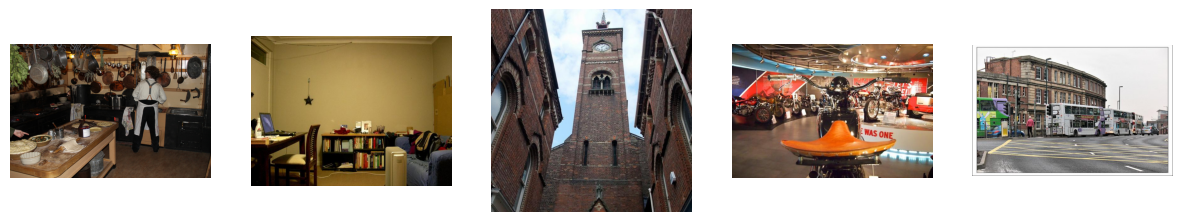

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

image_files = os.listdir("images")[:5]

plt.figure(figsize=(15,5))

for i, img_file in enumerate(image_files):
    img = cv2.imread(os.path.join("images", img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [ ]:
import cv2
import numpy as np

def motion_blur(image, kernel_size=15, angle=0):

    kernel = np.zeros((kernel_size, kernel_size))

    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)

    center = (kernel_size/2 - 0.5, kernel_size/2 - 0.5)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1)

    kernel = cv2.warpAffine(
        kernel,
        rotation_matrix,
        (kernel_size, kernel_size)
    )

    kernel = kernel / np.sum(kernel)

    blurred = cv2.filter2D(image, -1, kernel)

    return blurred

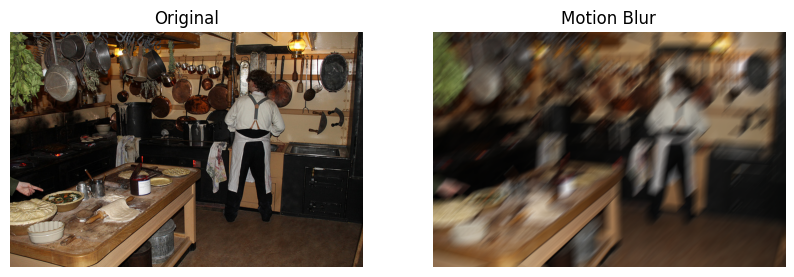

In [ ]:
img_path = os.path.join("images", image_files[0])

img = cv2.imread(img_path)

blurred = motion_blur(
    img,
    kernel_size=25,
    angle=45
)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
blur_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur_rgb)
plt.title("Motion Blur")
plt.axis("off")

plt.show()

In [ ]:
import os
import cv2
import random

os.makedirs("blurred_images", exist_ok=True)

image_files = os.listdir("images")

for img_file in image_files:

    img_path = os.path.join("images", img_file)

    img = cv2.imread(img_path)

    # Random blur settings
    kernel_size = random.choice([15, 25, 45])
    angle = random.randint(0, 180)

    blurred = motion_blur(
        img,
        kernel_size=kernel_size,
        angle=angle
    )

    save_path = os.path.join(
        "blurred_images",
        img_file
    )

    cv2.imwrite(save_path, blurred)

print("Blurred images created:", len(os.listdir("blurred_images")))

Blurred images created: 102


In [ ]:
len(os.listdir("images"))

102

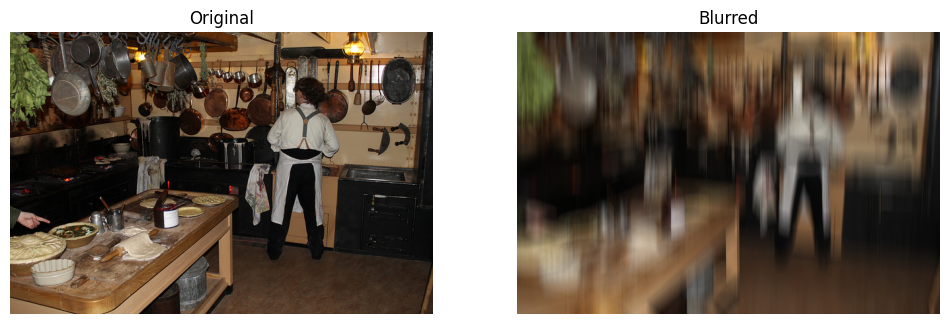

In [ ]:
import matplotlib.pyplot as plt

sample = image_files[0]

orig = cv2.imread(
    os.path.join("images", sample)
)

blur = cv2.imread(
    os.path.join("blurred_images", sample)
)

orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
blur = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur)
plt.title("Blurred")
plt.axis("off")

plt.show()

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n loaded successfully!")

YOLOv8n loaded successfully!



image 1/1 /content/images/397133.jpg: 448x640 2 persons, 1 cup, 4 bowls, 1 potted plant, 1 oven, 20.3ms
Speed: 1.6ms preprocess, 20.3ms inference, 2.9ms postprocess per image at shape (1, 3, 448, 640)


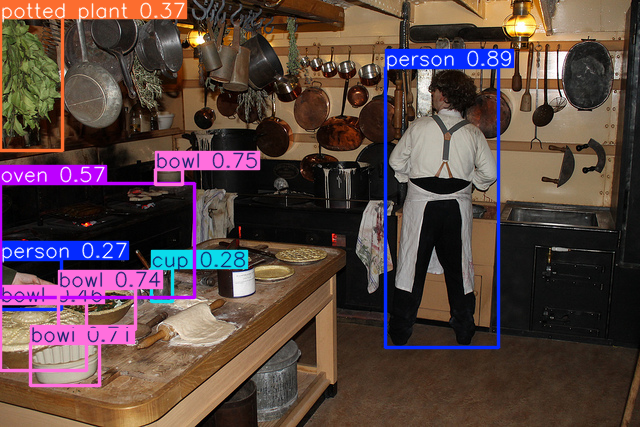

In [ ]:
import os

sample_image = os.path.join(
    "images",
    os.listdir("images")[0]
)

results = model(sample_image)

results[0].show()


image 1/1 /content/blurred_images/397133.jpg: 448x640 (no detections), 42.2ms
Speed: 7.9ms preprocess, 42.2ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


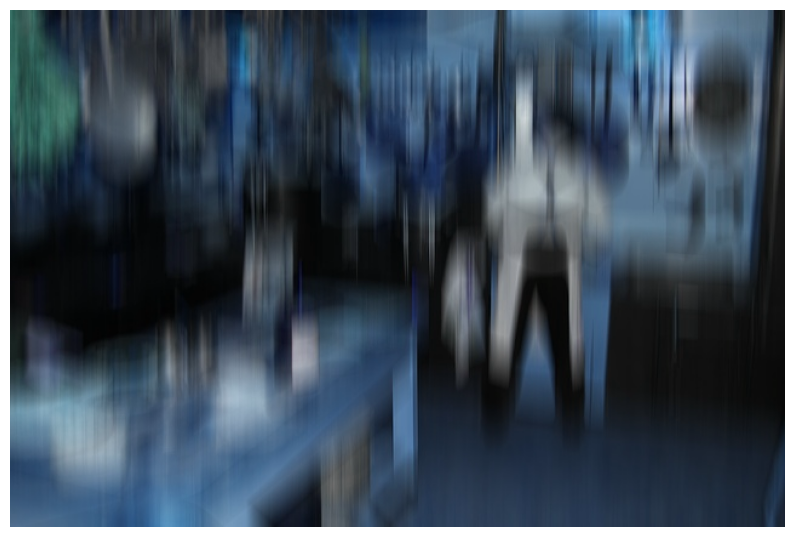

In [ ]:
sample_name = os.listdir("images")[0]

blurred_path = os.path.join(
    "blurred_images",
    sample_name
)

results_blur = model(blurred_path)

annotated_blur = results_blur[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated_blur)
plt.axis("off")
plt.show()

In [ ]:
results_blur = model(blurred_path)

print("Number of detections:", len(results_blur[0].boxes))


image 1/1 /content/blurred_images/397133.jpg: 448x640 (no detections), 16.5ms
Speed: 4.9ms preprocess, 16.5ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Number of detections: 0


In [ ]:
import random
import os

for _ in range(3):
    img_name = random.choice(os.listdir("blurred_images"))
    result = model(os.path.join("blurred_images", img_name))
    print(img_name, "->", len(result[0].boxes))


image 1/1 /content/blurred_images/img_93.jpg: 480x640 1 person, 53.2ms
Speed: 8.4ms preprocess, 53.2ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
img_93.jpg -> 1

image 1/1 /content/blurred_images/img_70.jpg: 448x640 (no detections), 6.9ms
Speed: 2.2ms preprocess, 6.9ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)
img_70.jpg -> 0

image 1/1 /content/blurred_images/img_93.jpg: 480x640 1 person, 7.1ms
Speed: 1.8ms preprocess, 7.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
img_93.jpg -> 1


In [ ]:
import os
import pandas as pd

results_data = []

image_files = os.listdir("images")

for img_file in image_files:

    img_path = os.path.join("images", img_file)

    results = model(img_path)

    num_detections = len(results[0].boxes)

    if num_detections > 0:
        avg_conf = float(results[0].boxes.conf.mean())
    else:
        avg_conf = 0

    results_data.append([
        img_file,
        num_detections,
        avg_conf
    ])

df_original = pd.DataFrame(
    results_data,
    columns=[
        "image",
        "detections",
        "avg_confidence"
    ]
)

print(df_original.head())


image 1/1 /content/images/397133.jpg: 448x640 2 persons, 1 cup, 4 bowls, 1 potted plant, 1 oven, 19.7ms
Speed: 3.3ms preprocess, 19.7ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_87.jpg: 480x640 1 backpack, 1 suitcase, 1 bottle, 1 chair, 1 dining table, 1 laptop, 9.2ms
Speed: 2.5ms preprocess, 9.2ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/images/img_80.jpg: 640x640 1 clock, 10.3ms
Speed: 3.6ms preprocess, 10.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_98.jpg: 448x640 2 motorcycles, 1 truck, 10.0ms
Speed: 1.6ms preprocess, 10.0ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_7.jpg: 448x640 1 person, 2 cars, 2 buss, 3 traffic lights, 7.7ms
Speed: 1.5ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_27.jpg: 480x640 2 broc

In [ ]:
print("Average detections:",
      df_original["detections"].mean())

print("Average confidence:",
      df_original["avg_confidence"].mean())

Average detections: 5.647058823529412
Average confidence: 0.6079287204672309


In [ ]:
results_blur = []

blur_files = os.listdir("blurred_images")

for img_file in blur_files:

    img_path = os.path.join(
        "blurred_images",
        img_file
    )

    results = model(img_path)

    num_detections = len(results[0].boxes)

    if num_detections > 0:
        avg_conf = float(
            results[0].boxes.conf.mean()
        )
    else:
        avg_conf = 0

    results_blur.append([
        img_file,
        num_detections,
        avg_conf
    ])

df_blur = pd.DataFrame(
    results_blur,
    columns=[
        "image",
        "detections",
        "avg_confidence"
    ]
)

print(df_blur.head())


image 1/1 /content/blurred_images/397133.jpg: 448x640 (no detections), 26.6ms
Speed: 3.1ms preprocess, 26.6ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_87.jpg: 480x640 (no detections), 12.2ms
Speed: 2.6ms preprocess, 12.2ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/blurred_images/img_80.jpg: 640x640 1 person, 10.7ms
Speed: 2.5ms preprocess, 10.7ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_98.jpg: 448x640 1 person, 8.7ms
Speed: 1.8ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_7.jpg: 448x640 1 person, 1 train, 8.5ms
Speed: 1.5ms preprocess, 8.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_27.jpg: 480x640 (no detections), 11.5ms
Speed: 2.7ms preprocess, 11.5ms inference, 0.8ms postproce

In [ ]:
print("Average detections:",
      df_blur["detections"].mean())

print("Average confidence:",
      df_blur["avg_confidence"].mean())

Average detections: 1.3137254901960784
Average confidence: 0.3239340992534862


In [ ]:
from ultralytics import YOLO

model_s = YOLO("yolov8s.pt")

print("YOLOv8s loaded successfully!")

YOLOv8s loaded successfully!


In [ ]:
import os
import pandas as pd

results_s_original = []

for img_file in os.listdir("images"):

    img_path = os.path.join(
        "images",
        img_file
    )

    results = model_s(img_path)

    num_detections = len(results[0].boxes)

    if num_detections > 0:
        avg_conf = float(
            results[0].boxes.conf.mean()
        )
    else:
        avg_conf = 0

    results_s_original.append([
        img_file,
        num_detections,
        avg_conf
    ])

df_s_original = pd.DataFrame(
    results_s_original,
    columns=[
        "image",
        "detections",
        "avg_confidence"
    ]
)

print(df_s_original.head())


image 1/1 /content/images/397133.jpg: 448x640 2 persons, 2 cups, 1 knife, 6 spoons, 6 bowls, 1 potted plant, 1 dining table, 2 ovens, 1 sink, 41.1ms
Speed: 1.8ms preprocess, 41.1ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_87.jpg: 480x640 1 backpack, 1 suitcase, 1 bottle, 1 chair, 1 bed, 1 dining table, 1 laptop, 37.2ms
Speed: 1.4ms preprocess, 37.2ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/images/img_80.jpg: 640x640 1 clock, 16.9ms
Speed: 1.5ms preprocess, 16.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_98.jpg: 448x640 1 car, 4 motorcycles, 13.4ms
Speed: 1.3ms preprocess, 13.4ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_7.jpg: 448x640 1 person, 2 cars, 4 buss, 3 traffic lights, 12.7ms
Speed: 1.5ms preprocess, 12.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

In [ ]:
print(
    "Average detections:",
    df_s_original["detections"].mean()
)

print(
    "Average confidence:",
    df_s_original["avg_confidence"].mean()
)

Average detections: 6.578431372549019
Average confidence: 0.652146932833335


In [ ]:
results_s_blur = []

for img_file in os.listdir("blurred_images"):

    img_path = os.path.join(
        "blurred_images",
        img_file
    )

    results = model_s(img_path)

    num_detections = len(results[0].boxes)

    if num_detections > 0:
        avg_conf = float(
            results[0].boxes.conf.mean()
        )
    else:
        avg_conf = 0

    results_s_blur.append([
        img_file,
        num_detections,
        avg_conf
    ])

df_s_blur = pd.DataFrame(
    results_s_blur,
    columns=[
        "image",
        "detections",
        "avg_confidence"
    ]
)

print(df_s_blur.head())


image 1/1 /content/blurred_images/397133.jpg: 448x640 (no detections), 14.2ms
Speed: 2.0ms preprocess, 14.2ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_87.jpg: 480x640 (no detections), 13.8ms
Speed: 1.3ms preprocess, 13.8ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/blurred_images/img_80.jpg: 640x640 1 person, 17.1ms
Speed: 1.7ms preprocess, 17.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_98.jpg: 448x640 1 skateboard, 13.5ms
Speed: 1.5ms preprocess, 13.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_7.jpg: 448x640 1 person, 2 cars, 4 buss, 1 traffic light, 12.8ms
Speed: 1.7ms preprocess, 12.8ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_27.jpg: 480x640 (no detections), 13.7ms
Speed: 2.4ms preprocess, 1

In [ ]:
print(
    "Average detections:",
    df_s_blur["detections"].mean()
)

print(
    "Average confidence:",
    df_s_blur["avg_confidence"].mean()
)

Average detections: 1.5098039215686274
Average confidence: 0.36803245748959335


In [ ]:
from ultralytics import RTDETR

rtdetr_model = RTDETR("rtdetr-l.pt")

print("RT-DETR loaded successfully!")

RT-DETR loaded successfully!


In [ ]:
import random
import os

test_img = random.choice(os.listdir("images"))

result = rtdetr_model(os.path.join("images", test_img))

print("Detections:", len(result[0].boxes))


image 1/1 /content/images/img_11.jpg: 640x640 5 bottles, 1 toilet, 4 sinks, 71.4ms
Speed: 4.9ms preprocess, 71.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Detections: 10


In [ ]:
import os
import pandas as pd

results_original_rtdetr = []

for img_name in os.listdir("images"):
    img_path = os.path.join("images", img_name)

    result = rtdetr_model(img_path)

    detections = len(result[0].boxes)

    if detections > 0:
        avg_conf = float(result[0].boxes.conf.mean())
    else:
        avg_conf = 0

    results_original_rtdetr.append(
        [img_name, detections, avg_conf]
    )

df_rtdetr_original = pd.DataFrame(
    results_original_rtdetr,
    columns=["image", "detections", "avg_confidence"]
)

df_rtdetr_original.head()


image 1/1 /content/images/397133.jpg: 640x640 2 persons, 2 bottles, 2 cups, 4 knifes, 8 spoons, 10 bowls, 1 pizza, 1 potted plant, 1 dining table, 4 ovens, 1 sink, 73.0ms
Speed: 3.6ms preprocess, 73.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_87.jpg: 640x640 1 backpack, 1 bottle, 2 chairs, 5 couchs, 5 beds, 1 dining table, 1 tv, 1 laptop, 1 mouse, 1 remote, 33 books, 72.1ms
Speed: 2.5ms preprocess, 72.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_80.jpg: 640x640 1 clock, 73.5ms
Speed: 2.7ms preprocess, 73.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_98.jpg: 640x640 16 motorcycles, 60.2ms
Speed: 3.7ms preprocess, 60.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_7.jpg: 640x640 2 persons, 5 cars, 5 buss, 5 traffic lights, 57.4ms
Speed: 2.1ms preprocess, 57.4ms inference, 0

,image,detections,avg_confidence
0,397133.jpg,36,0.477328
1,img_87.jpg,52,0.375398
2,img_80.jpg,1,0.868772
3,img_98.jpg,16,0.501721
4,img_7.jpg,17,0.658972


In [ ]:
print(
    "Average detections:",
    df_rtdetr_original["detections"].mean()
)

print(
    "Average confidence:",
    df_rtdetr_original["avg_confidence"].mean()
)

Average detections: 14.823529411764707
Average confidence: 0.5982045221562479


In [ ]:
results_blur_rtdetr = []

for img_name in os.listdir("blurred_images"):
    img_path = os.path.join("blurred_images", img_name)

    result = rtdetr_model(img_path)

    detections = len(result[0].boxes)

    if detections > 0:
        avg_conf = float(result[0].boxes.conf.mean())
    else:
        avg_conf = 0

    results_blur_rtdetr.append(
        [img_name, detections, avg_conf]
    )

df_rtdetr_blur = pd.DataFrame(
    results_blur_rtdetr,
    columns=["image", "detections", "avg_confidence"]
)

df_rtdetr_blur.head()


image 1/1 /content/blurred_images/397133.jpg: 640x640 3 persons, 1 bench, 1 dining table, 72.5ms
Speed: 3.3ms preprocess, 72.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_87.jpg: 640x640 2 suitcases, 72.6ms
Speed: 2.2ms preprocess, 72.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_80.jpg: 640x640 2 buss, 63.7ms
Speed: 2.3ms preprocess, 63.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_98.jpg: 640x640 2 persons, 2 cars, 2 boats, 2 umbrellas, 1 surfboard, 58.9ms
Speed: 2.0ms preprocess, 58.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_7.jpg: 640x640 1 person, 4 cars, 6 buss, 1 truck, 55.1ms
Speed: 2.5ms preprocess, 55.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_27.jpg: 640x640 2 car

,image,detections,avg_confidence
0,397133.jpg,5,0.297716
1,img_87.jpg,2,0.319950
2,img_80.jpg,2,0.620619
3,img_98.jpg,9,0.330033
4,img_7.jpg,12,0.471646


In [ ]:
print(
    "Average detections:",
    df_rtdetr_blur["detections"].mean()
)

print(
    "Average confidence:",
    df_rtdetr_blur["avg_confidence"].mean()
)

Average detections: 6.872549019607843
Average confidence: 0.4655751238266627


In [ ]:
import random
import os

# Choose a random image from the original images directory
fixed_img = random.choice(os.listdir("/content/images"))

print("Selected image:", fixed_img)

Selected image: img_86.jpg



image 1/1 /content/blurred_images/img_67.jpg: 448x640 (no detections), 11.1ms
Speed: 2.0ms preprocess, 11.1ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)


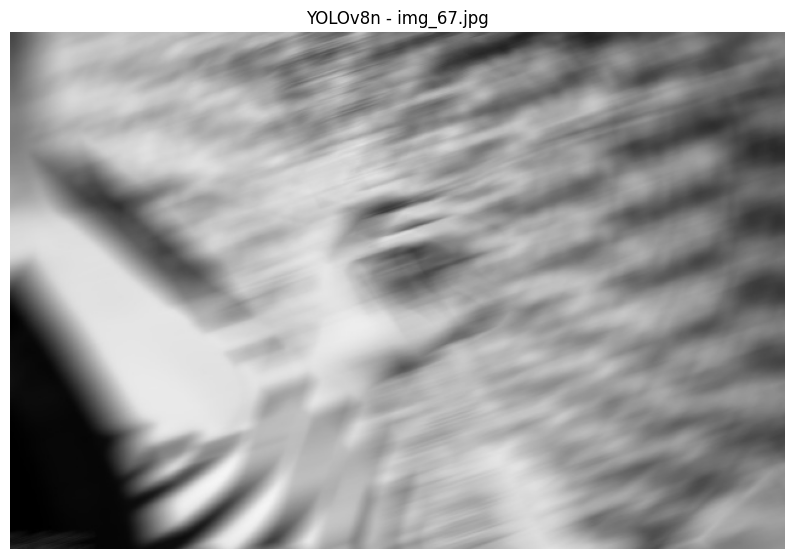

In [ ]:
import os
import matplotlib.pyplot as plt

img_path = os.path.join("blurred_images", fixed_img)

result = model(img_path)

annotated = result[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.title(f"YOLOv8n - {fixed_img}")
plt.show()


image 1/1 /content/blurred_images/img_67.jpg: 448x640 (no detections), 13.8ms
Speed: 2.2ms preprocess, 13.8ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


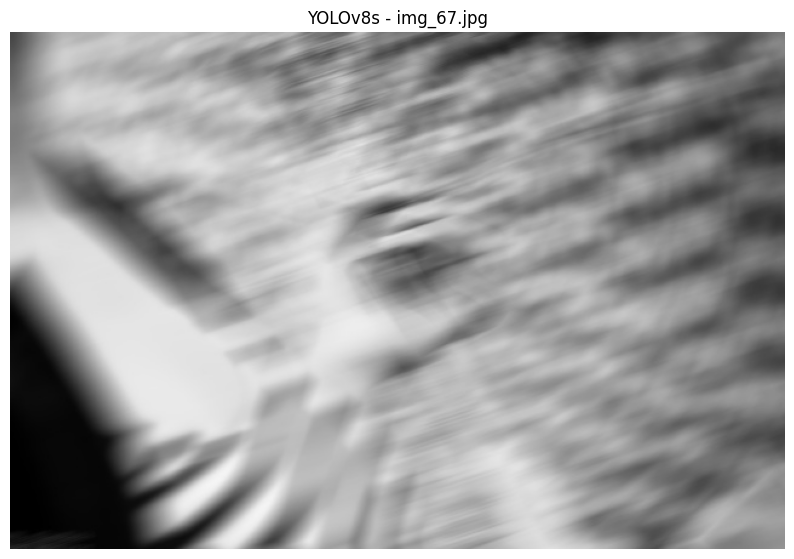

In [ ]:
import os
import matplotlib.pyplot as plt

img_path = os.path.join("blurred_images", fixed_img)

result = model_s(img_path)

annotated = result[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.title(f"YOLOv8s - {fixed_img}")
plt.show()


image 1/1 /content/blurred_images/img_67.jpg: 640x640 1 bench, 1 umbrella, 1 tv, 93.0ms
Speed: 4.4ms preprocess, 93.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


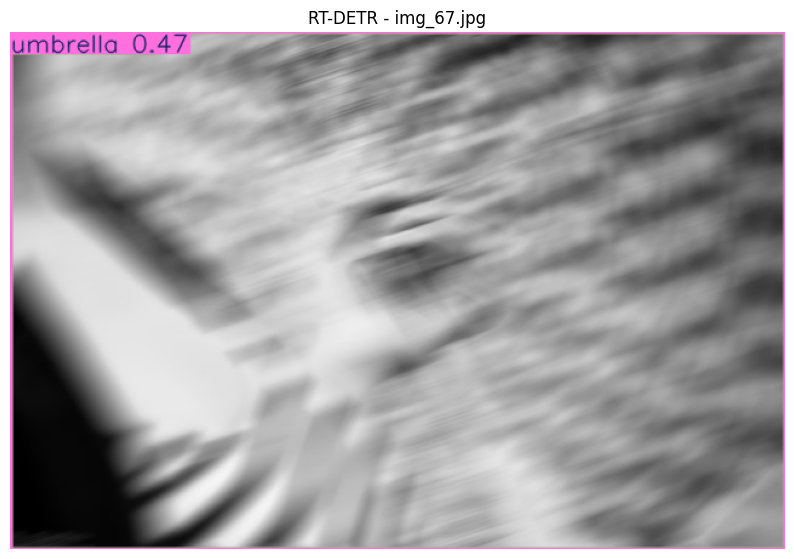

In [ ]:
import os
import matplotlib.pyplot as plt

img_path = os.path.join("blurred_images", fixed_img)

result = rtdetr_model(img_path)

annotated = result[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.title(f"RT-DETR - {fixed_img}")
plt.show()

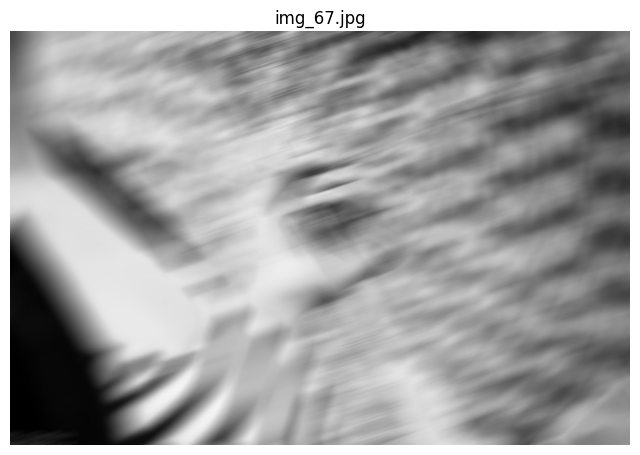

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

img_path = os.path.join("blurred_images", fixed_img)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title(fixed_img)
plt.show()

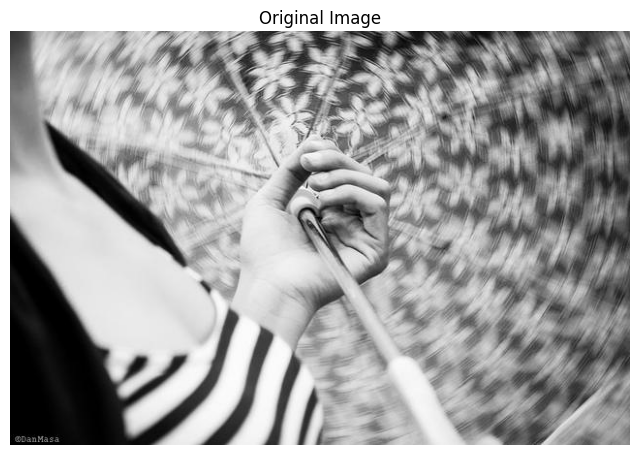

In [ ]:
original_path = os.path.join("images", fixed_img)

img = cv2.imread(original_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [ ]:
!pip install -q transformers
!pip install -q timm
!pip install -q pillow

In [ ]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

gnd_processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
gnd_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    "IDEA-Research/grounding-dino-base"
).to(device)

print("GroundingDINO loaded!")

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

GroundingDINO loaded!


In [ ]:
import os
print(os.getcwd())

/content/GroundingDINO


In [ ]:
!ls /content

blurred_images	images	     sample_data  yolov8s.pt
GroundingDINO	rtdetr-l.pt  yolov8n.pt


In [ ]:
print(os.listdir("/content/images")[:5])

['397133.jpg', 'img_87.jpg', 'img_80.jpg', 'img_98.jpg', 'img_7.jpg']


In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
import inspect

print(inspect.signature(processor.post_process_grounded_object_detection))

(outputs: 'GroundingDinoObjectDetectionOutput', input_ids: transformers.utils.generic.TensorType | None = None, threshold: float = 0.25, text_threshold: float = 0.25, target_sizes: transformers.utils.generic.TensorType | list[tuple] | None = None, text_labels: list[list[str]] | None = None)


In [ ]:
from PIL import Image
import os
import torch

img_path = "/content/images/" + os.listdir("/content/images")[0]

image = Image.open(img_path).convert("RGB")

inputs = processor(
    images=image,
    text="person. car. bicycle. dog. cat. umbrella.",
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.3,
    text_threshold=0.25,
    target_sizes=[image.size[::-1]]
)

print("Detections:", len(results[0]["boxes"]))

Detections: 2


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


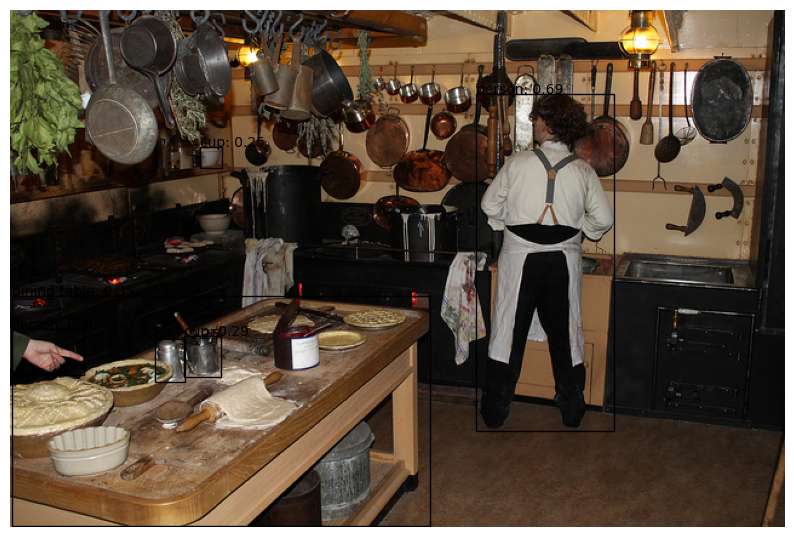

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

img_path = "/content/images/" + os.listdir("/content/images")[0]

image = Image.open(img_path).convert("RGB")

inputs = processor(
    images=image,
    text = """
person. bicycle. car. motorcycle. airplane. bus. train.
truck. boat. traffic light. fire hydrant. stop sign.
bench. bird. cat. dog. horse. sheep. cow.
elephant. bear. zebra. giraffe. backpack. umbrella.
handbag. suitcase. bottle. cup. chair. couch.
potted plant. bed. dining table. laptop. mouse.
keyboard. cell phone. book.
""",
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.25,
    text_threshold=0.25,
    target_sizes=[image.size[::-1]]
)

boxes = results[0]["boxes"]
scores = results[0]["scores"]
labels = results[0]["labels"]

fig, ax = plt.subplots(figsize=(10,8))
ax.imshow(image)

for box, score, label in zip(boxes, scores, labels):
    x1, y1, x2, y2 = box.tolist()

    rect = patches.Rectangle(
        (x1,
        y1),
        x2-x1,
        y2-y1,
        fill=False
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        f"{label}: {score:.2f}"
    )

plt.axis("off")
plt.show()

In [ ]:
import pandas as pd
import os
from PIL import Image
import torch

TEXT_PROMPT = """
person. bicycle. car. motorcycle. airplane. bus. train.
truck. boat. traffic light. fire hydrant. stop sign.
bench. bird. cat. dog. horse. sheep. cow.
elephant. bear. zebra. giraffe. backpack. umbrella.
handbag. suitcase. bottle. cup. chair. couch.
potted plant. bed. dining table. laptop. mouse.
keyboard. cell phone. book.
"""

image_folder = "/content/images"

orig_results = []

for img_name in os.listdir(image_folder):
    img_path = os.path.join(image_folder, img_name)
    image = Image.open(img_path).convert("RGB")

    inputs = processor(
        images=image,
        text=TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.3,
        text_threshold=0.3,
        target_sizes=[image.size[::-1]]
    )

    scores = results[0]["scores"]

    det_count = (scores > 0.3).sum().item()
    avg_conf = scores.mean().item() if len(scores) > 0 else 0

    orig_results.append({
        "image": img_name,
        "detections": det_count,
        "avg_confidence": avg_conf
    })

df_orig = pd.DataFrame(orig_results)

print("GroundingDINO - Original")
print("Avg detections:", df_orig["detections"].mean())
print("Avg confidence:", df_orig["avg_confidence"].mean())

df_orig.head()

GroundingDINO - Original
Avg detections: 6.9411764705882355
Avg confidence: 0.4708304270809772


,image,detections,avg_confidence
0,397133.jpg,3,0.479874
1,img_87.jpg,8,0.560859
2,img_80.jpg,0,0.000000
3,img_98.jpg,10,0.371145
4,img_7.jpg,12,0.615528


In [ ]:
import pandas as pd
import os
from PIL import Image
import torch

TEXT_PROMPT = """
person. bicycle. car. motorcycle. airplane. bus. train.
truck. boat. traffic light. fire hydrant. stop sign.
bench. bird. cat. dog. horse. sheep. cow.
elephant. bear. zebra. giraffe. backpack. umbrella.
handbag. suitcase. bottle. cup. chair. couch.
potted plant. bed. dining table. laptop. mouse.
keyboard. cell phone. book.
"""

image_folder = "/content/blurred_images"

blur_results = []

for img_name in os.listdir(image_folder):
    img_path = os.path.join(image_folder, img_name)
    image = Image.open(img_path).convert("RGB")

    inputs = processor(
        images=image,
        text=TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.3,
        text_threshold=0.3,
        target_sizes=[image.size[::-1]]
    )

    scores = results[0]["scores"]

    det_count = (scores > 0.3).sum().item()
    avg_conf = scores.mean().item() if len(scores) > 0 else 0

    blur_results.append({
        "image": img_name,
        "detections": det_count,
        "avg_confidence": avg_conf
    })

df_blur = pd.DataFrame(blur_results)

print("GroundingDINO - Blurred")
print("Avg detections:", df_blur["detections"].mean())
print("Avg confidence:", df_blur["avg_confidence"].mean())

df_blur.head()

GroundingDINO - Blurred
Avg detections: 2.7058823529411766
Avg confidence: 0.4031617410627066


,image,detections,avg_confidence
0,397133.jpg,2,0.453046
1,img_87.jpg,0,0.000000
2,img_80.jpg,0,0.000000
3,img_98.jpg,1,0.441234
4,img_7.jpg,8,0.482594


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


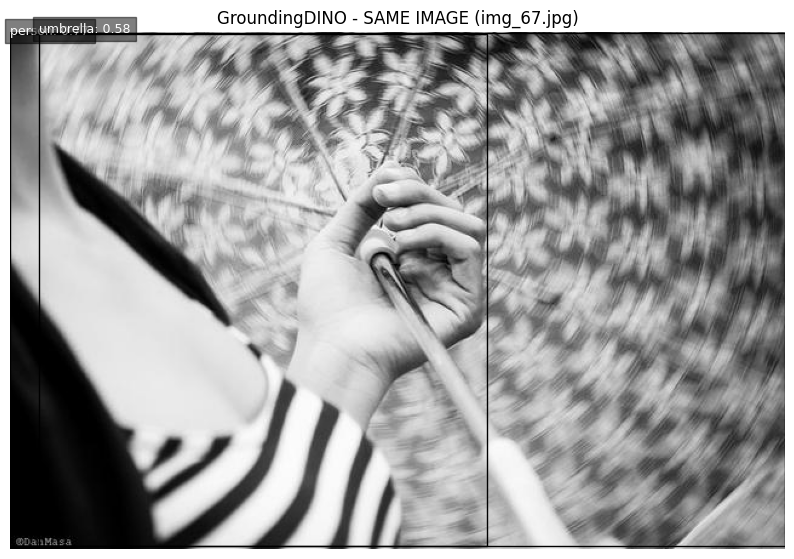

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

TEXT_PROMPT = """
person. bicycle. car. motorcycle. airplane. bus. train.
truck. boat. traffic light. fire hydrant. stop sign.
bench. bird. cat. dog. horse. sheep. cow.
elephant. bear. zebra. giraffe. backpack. umbrella.
handbag. suitcase. bottle. cup. chair. couch.
potted plant. bed. dining table. laptop. mouse.
keyboard. cell phone. book.
"""

# SAME IMAGE USED FOR ALL MODELS
fixed_img = "img_67.jpg"
img_path = "/content/images/" + fixed_img

image = Image.open(img_path).convert("RGB")

# Inference
inputs = processor(
    images=image,
    text=TEXT_PROMPT,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-process
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.3,
    text_threshold=0.3,
    target_sizes=[image.size[::-1]]
)

boxes = results[0]["boxes"]
scores = results[0]["scores"]
labels = results[0]["labels"]

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image)

for box, score, label in zip(boxes, scores, labels):
    if score < 0.3:
        continue

    x1, y1, x2, y2 = box.tolist()

    rect = patches.Rectangle(
        (x1,
        y1),
        x2 - x1,
        y2 - y1,
        fill=False
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        f"{label}: {score:.2f}",
        fontsize=9,
        color="white",
        bbox=dict(facecolor="black", alpha=0.5)
    )

plt.axis("off")
plt.title("GroundingDINO - SAME IMAGE (img_67.jpg)")
plt.show()

In [ ]:
print("Scores:", results[0]["scores"])
print("Max score:", results[0]["scores"].max() if len(results[0]["scores"]) > 0 else 0)
print("Num raw boxes:", len(results[0]["boxes"]))

Scores: tensor([0.2645, 0.2506, 0.1846, 0.1822], device='cuda:0')
Max score: tensor(0.2645, device='cuda:0')
Num raw boxes: 4


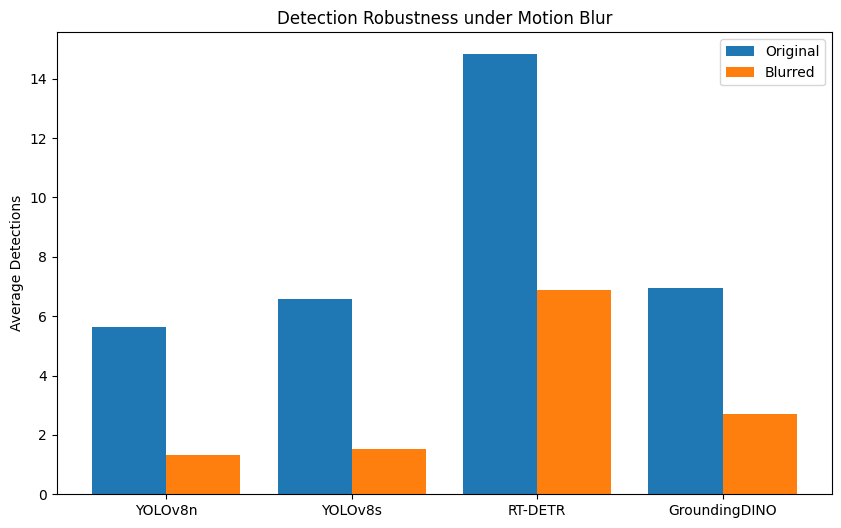

In [ ]:
import matplotlib.pyplot as plt

models = ["YOLOv8n", "YOLOv8s", "RT-DETR", "GroundingDINO"]

orig = [5.65, 6.58, 14.82, 6.94]
blur = [1.31, 1.51, 6.87, 2.71]

x = range(len(models))

plt.figure(figsize=(10,6))
plt.bar(x, orig, width=0.4, label="Original")
plt.bar([i + 0.4 for i in x], blur, width=0.4, label="Blurred")

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("Average Detections")
plt.title("Detection Robustness under Motion Blur")
plt.legend()
plt.show()

In [ ]:
yolov8n_avg_detections_orig = df_original["detections"].mean()
yolov8n_avg_confidence_orig = df_original["avg_confidence"].mean()

yolov8n_avg_detections_blur = df_blur["detections"].mean()
yolov8n_avg_confidence_blur = df_blur["avg_confidence"].mean()

yolov8s_avg_detections_orig = df_s_original["detections"].mean()
yolov8s_avg_confidence_orig = df_s_original["avg_confidence"].mean()

yolov8s_avg_detections_blur = df_s_blur["detections"].mean()
yolov8s_avg_confidence_blur = df_s_blur["avg_confidence"].mean()

rtdetr_avg_detections_orig = df_rtdetr_original["detections"].mean()
rtdetr_avg_confidence_orig = df_rtdetr_original["avg_confidence"].mean()

rtdetr_avg_detections_blur = df_rtdetr_blur["detections"].mean()
rtdetr_avg_confidence_blur = df_rtdetr_blur["avg_confidence"].mean()

gdino_avg_detections_orig = df_orig["detections"].mean()
gdino_avg_confidence_orig = df_orig["avg_confidence"].mean()

gdino_avg_detections_blur = df_blur["detections"].mean()
gdino_avg_confidence_blur = df_blur["avg_confidence"].mean()


comparison_data = {
    'Model': ['YOLOv8n', 'YOLOv8s', 'RT-DETR', 'GroundingDINO'],
    'Original Avg Detections': [
        yolov8n_avg_detections_orig,
        yolov8s_avg_detections_orig,
        rtdetr_avg_detections_orig,
        gdino_avg_detections_orig
    ],
    'Original Avg Confidence': [
        yolov8n_avg_confidence_orig,
        yolov8s_avg_confidence_orig,
        rtdetr_avg_confidence_orig,
        gdino_avg_confidence_orig
    ],
    'Blurred Avg Detections': [
        yolov8n_avg_detections_blur,
        yolov8s_avg_detections_blur,
        rtdetr_avg_detections_blur,
        gdino_avg_detections_blur
    ],
    'Blurred Avg Confidence': [
        yolov8n_avg_confidence_blur,
        yolov8s_avg_confidence_blur,
        rtdetr_avg_confidence_blur,
        gdino_avg_confidence_blur
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

,Model,Original Avg Detections,Original Avg Confidence,Blurred Avg Detections,Blurred Avg Confidence
0,YOLOv8n,5.647059,0.607929,2.705882,0.403162
1,YOLOv8s,6.578431,0.652147,1.509804,0.368032
2,RT-DETR,14.823529,0.598205,6.872549,0.465575
3,GroundingDINO,6.941176,0.470830,2.705882,0.403162


In [ ]:
import torch
import transformers
import ultralytics
import cv2
import pandas as pd
import numpy as np

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Transformers:", transformers.__version__)
print("Ultralytics:", ultralytics.__version__)
print("OpenCV:", cv2.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

PyTorch: 2.11.0+cu128
CUDA: 12.8
Transformers: 5.0.0
Ultralytics: 8.4.60
OpenCV: 4.13.0
Pandas: 2.2.2
NumPy: 2.0.2
